<a href="https://colab.research.google.com/github/davulatan/software-engineering-Phase4/blob/main/Phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exploratory Data Analysis (EDA)**

/tmp/ipykernel_9010/4098083137.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='survived', palette='viridis')


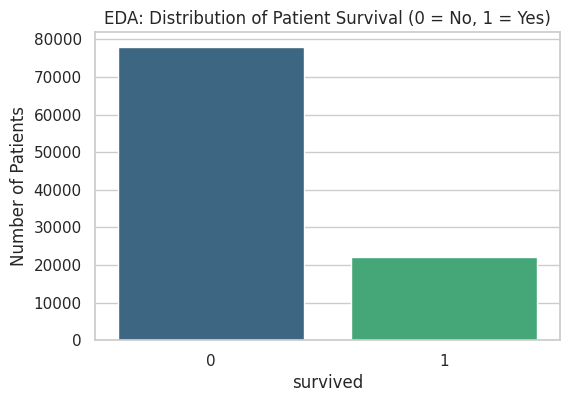

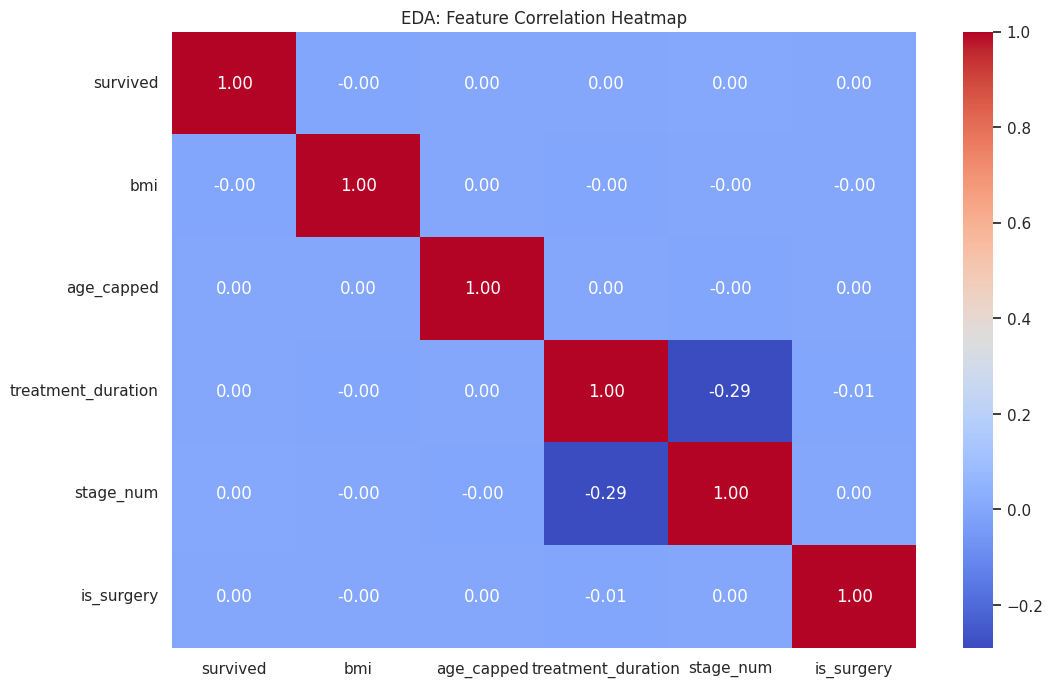

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paste your copied RAW URL here
url = "https://raw.githubusercontent.com/cksumalinog/software-engineering-phase-4/refs/heads/main/Lung%20Cancer(100k)(Classification).csv"

# Reload the dataset back into Colab's memory
df = pd.read_csv(url)

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Target Distribution (Shows the Class Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='survived', palette='viridis')
plt.title('EDA: Distribution of Patient Survival (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

# 2. Correlation Heatmap (Shows relationships between all variables)
plt.figure(figsize=(12, 8))
# Taking a sample of columns to keep the heatmap readable
cols_to_plot = ['survived', 'bmi', 'age_capped', 'treatment_duration', 'stage_num', 'is_surgery']
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('EDA: Feature Correlation Heatmap')
plt.show()

**Feature Importance Analysis**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Reload the dataset back into Colab's memory
#df = pd.read_csv("Lung Cancer(100k)(Classification).csv")
url = "https://raw.githubusercontent.com/cksumalinog/software-engineering-phase-4/refs/heads/main/Lung%20Cancer(100k)(Classification).csv"

# Reload the dataset back into Colab's memory
df = pd.read_csv(url)

# 1. Re-split the data (using the 'df' you just reloaded)
X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# 2. Re-train the Random Forest model
print("Retraining the model quickly...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model restored! You can now run your chart code.")

FileNotFoundError: [Errno 2] No such file or directory: 'Lung Cancer(100k)(Classification).csv'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importances from the trained Random Forest
importances = rf_model.feature_importances_

# 2. Get the names of the features from the training data
feature_names = X_train.columns

# 3. Create a DataFrame to sort the features by importance
feature_importance_df = pd.DataFrame({
    'Patient Features': feature_names,
    'Importance Score': importances
})

# Sort the features from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(by='Importance Score', ascending=False)

# 4. Plot the beautiful horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df,
    x='Importance Score',
    y='Patient Features',
    palette='viridis' # This gives you that clean purple-to-green gradient!
)

plt.title('Random Forest Feature Importance for Predicting Survival', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Patient Features', fontsize=12)
plt.tight_layout()
plt.show()

**Actual vs Predicted & Residual Analysis**

In [ ]:
import numpy as np

# Get the probability predictions (how confident the model was from 0% to 100%)
# Assuming you are using your Random Forest model (rf_model)
y_pred_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate Classification Residuals (Actual - Predicted Probability)
residuals = y_test - y_pred_probs

# 1. Actual vs Predicted Plot (Boxplot format for Classification)
plt.figure(figsize=(8, 5))
sns.boxplot(x=y_test, y=y_pred_probs, palette='Set2')
plt.title('Actual vs. Predicted Probabilities')
plt.xlabel('Actual Survival (0 = No, 1 = Yes)')
plt.ylabel('Predicted Probability of Survival')
plt.show()

# 2. Residual Analysis Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_probs, y=residuals, alpha=0.3, color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Analysis (Prediction Errors)')
plt.xlabel('Predicted Probability')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

**Classification Model Visuals**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Generate the visual Confusion Matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues',
    colorbar=False
)
plt.title('Classification Visual: Confusion Matrix')
plt.grid(False) # Turns off the background grid for a cleaner look
plt.show()